Maglab processes phase information

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import maglab
import torch
import torch.nn.functional as F
import os
import h5py
from scipy.optimize import curve_fit
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import rotate

In [ ]:
N = 206
dx = 1.06e-9
Ms = 3.84e5
geo = maglab.geo.cylider(136, 111)
nx, ny, nz = geo.shape
micro = maglab.Micro(nx, ny, nz, dx)
phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()

gauss_kernel_size = 99
sigma = maglab.preprocess.compute_sigma(gauss_kernel_size)
kernel = maglab.preprocess.gaussian_kernel(gauss_kernel_size, sigma)
kernel_groups = kernel.repeat(8, 1, 1, 1).cuda()
print(sigma)

def apply_filter(phase):
    phase1 = F.conv2d(phase.unsqueeze(0), kernel.repeat(1, 1, 1, 1).cuda(), groups=1, padding=gauss_kernel_size // 2)[0,]
    return (phase-phase1).data.cuda()

def load_spin(file_path):
    state = micro.load_state(f"{file_path}/final.pth")
    return state.spin#.detach().cpu().numpy()

def delta_phi(a, b, c):
    return np.mean(abs((a - b) * c)) / np.mean(abs(a * c))

def plot_phase_diff_histogram(index, phase_diff_data, mask, output_dir='phase_histograms', gauss_check=False, global_ymax=None):

    data_to_plot = phase_diff_data
    mask_bool = mask.astype(bool)
    masked_diff = data_to_plot[mask_bool].flatten()

    adjusted_masked_diff = masked_diff - 0  # phase shift
    data_to_use = adjusted_masked_diff

    # calculate range
    calc_min, calc_max = -0.5, 0.5
    data_for_calc = data_to_use[
        (data_to_use >= calc_min) & (data_to_use <= calc_max)
    ]

    # plot range
    plot_min, plot_max = -0.35, 0.35

    if not os.path.isdir(output_dir):
        os.makedirs(output_dir)

    fig, ax = plt.subplots(figsize=(3, 2), dpi=330)

    n, bins, patches = ax.hist(
        data_for_calc,
        bins=50,
        range=(calc_min, calc_max),
        color='skyblue',
        edgecolor='black',
        density=False,
        alpha=0.7
    )

    fit_sigma_value = None
    if gauss_check:
        bin_centers = (bins[:-1] + bins[1:]) / 2

        def gauss(x, A, mu, sigma):
            return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

        try:
            A_guess = np.max(n)
            mu_guess = np.mean(data_for_calc)
            sigma_guess = np.std(data_for_calc)

            popt, pcov = curve_fit(
                gauss,
                bin_centers,
                n,
                p0=[A_guess, mu_guess, sigma_guess]
            )

            A_fit, mu_fit, sigma_fit = popt
            fit_sigma_value = abs(sigma_fit)

            # 拟合曲线只画在显示范围内
            x_fit = np.linspace(plot_min, plot_max, 1000)
            y_fit = gauss(x_fit, A_fit, mu_fit, sigma_fit)

            ax.plot(
                x_fit,
                y_fit,
                'r-',
                linewidth=1.5,
                label=f'Gaussian fit\nμ={mu_fit:.3f}\nσ={sigma_fit:.3f}'
            )

            three_sigma_min = mu_fit - 3 * sigma_fit
            three_sigma_max = mu_fit + 3 * sigma_fit

            ax.axvline(
                x=three_sigma_min,
                color='orange',
                linestyle='--',
                linewidth=1,
                label=f'3σ range\n[{three_sigma_min:.3f}, {three_sigma_max:.3f}]'
            )
            ax.axvline(
                x=three_sigma_max,
                color='orange',
                linestyle='--',
                linewidth=1
            )

            data_in_3sigma = np.sum(
                (data_for_calc >= three_sigma_min) &
                (data_for_calc <= three_sigma_max)
            )
            total_data = len(data_for_calc)
            percent_in_3sigma = (data_in_3sigma / total_data) * 100

        except Exception as e:
            print(f"Gaussian fitting failed for index {index}: {str(e)}")
            ax.text(
                0.5,
                0.5,
                "Gauss Fit Failed",
                transform=ax.transAxes,
                verticalalignment='center',
                horizontalalignment='center',
                fontsize=10,
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.5)
            )
            fit_sigma_value = None

    # plot range
    ax.set_xlim(plot_min, plot_max)

    # unified y-axis
    if global_ymax is not None:
        ax.set_ylim(0, global_ymax * 1.7)

    # set ticks
    ax.set_xticks(np.arange(plot_min, plot_max + 0.01, 0.35))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=12)

    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylabel('Pixel Count', fontsize=12)
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, pos: '' if np.isclose(y, 0) else f'{int(y)}')
    )

    plt.tight_layout()
    file_name = f'{output_dir}/Phase_Diff_Histogram_{index}.png'
    plt.savefig(file_name, dpi=330, bbox_inches='tight')
    plt.close(fig)

    return fit_sigma_value

15.2


In [ ]:
phaseset = maglab.dataset.PhaseSet()
angles = [0, 28, 44, 50, 54, 58, 61, 65]
for alpha in angles:
    phasemap = torch.load(f"../recon-scripts/dataset/dm3_refin/refin_3dmask_pm/phasemap_{alpha}.pth")
    for item in phasemap:
        data  = item['data'].transpose((1,0))
        mask  = item['mask'].transpose((1,0))
        alpha = -item['alpha']
        phasemap = maglab.dataset.PhaseMap(data=data, mask=mask, alpha=alpha)
    phaseset.load(phasemap)
phaseset.sort()

/tmp/ipykernel_21829/3334971498.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phasemap = torch.load(f"/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/refin_3dmask

In [ ]:
state_calc = micro.load_state("../recon-scripts/dataset/phase_calc/w0_calc.pth")
spin_calc = state_calc.spin

l = 16
#state_pred = micro.load_state(f"../recon-scripts/separate/1_Eexc/results/loss1.6e+01_wphi1.0e+07/final.pth")
state_pred = micro.load_state(f"../recon-scripts/separate/loss16_analyse/no_Em/final.pth")
#state_pred = micro.load_state(f"../recon-scripts/test_phi/results/loss0.0e+00_wphi1.0e+07/final.pth")
#state_pred = micro.load_state(f"../recon-scripts/dmi_loss/{l:g}_layers_loss/results/loss{l:.1e}_wphi1.0e+07/final.pth")
spin_pred = state_pred.spin

/home/zhaoy/anaconda3/envs/tomopy/lib/python3.12/site-packages/maglab-0.1-py3.12.egg/maglab/micro.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
output_exp_dir = 'hdf5/exp_loss' 
os.makedirs(output_exp_dir, exist_ok=True)

output_pred_dir = 'hdf5/pred_loss' 
os.makedirs(output_pred_dir, exist_ok=True)

output_diff_dir = 'hdf5/diff_loss' 
os.makedirs(output_diff_dir, exist_ok=True)

output_calc_dir = 'hdf5/calc_loss' 
os.makedirs(output_calc_dir, exist_ok=True)

calc_min, calc_max = -0.5, 0.5
hist_bins = 50
global_ymax = 0

for angle in angles:
    phasediff_name = './hdf5/pred_loss/phase_{:g}.hdf5'.format(angle)

    with h5py.File(phasediff_name, 'r') as hf:
        phase = np.fliplr(
            rotate(hf['phase'][:], angle=90, reshape=False, order=1)
        )
        mask = np.fliplr(
            rotate(hf['mask'][:], angle=90, reshape=False, order=0)
        )

    mask_bool = mask.astype(bool)
    masked_diff = phase[mask_bool].flatten()

    data_for_calc = masked_diff[
        (masked_diff >= calc_min) &
        (masked_diff <= calc_max)
    ]

    counts, _ = np.histogram(
        data_for_calc,
        bins=hist_bins,
        range=(calc_min, calc_max)
    )

    global_ymax = max(global_ymax, np.max(counts))
    
sigma_list = []
for i in range(8):
    Euler = phaseset[i].Euler
    mask = phaseset[i].mask
    real_angle = abs(abs(Euler[0]))

    phi_exp = apply_filter(phaseset[i].data.cuda()) #* mask.cuda()
    phi_calc = apply_filter(phasemapper(spin_calc, *Euler, Ms=Ms))# * mask.cuda()
    phi_pred = apply_filter(phasemapper(spin_pred, *Euler, Ms=Ms))# * mask.cuda()
    phi_diff = (phi_calc - phi_pred) #* mask.cuda()

    # print(f"angle:{Euler}, delta:{delta_phi(phi_exp.detach().cpu().numpy(), phi_calc.detach().cpu().numpy(), mask.detach().cpu().numpy())}")

    sigma = plot_phase_diff_histogram(real_angle, phi_diff.detach().cpu().numpy(), mask.detach().cpu().numpy(), output_dir='phase_histograms',gauss_check=True)
    if sigma is not None:
        sigma = float(sigma)
        sigma_list.append((real_angle, sigma))
        print(f"Angle {real_angle:g} deg Sigma: {sigma:.6f}")
    else:
        print(f"Angle {real_angle:g} deg Sigma: fitting failed")

    output_path = 'phase_{:g}.hdf5'.format(real_angle)
    path_diff = os.path.join(output_calc_dir, output_path)
    with h5py.File(path_diff, 'w') as hf:
        hf.create_dataset('phase', data=phi_calc.detach().cpu().numpy().astype(np.float32))
        hf.create_dataset('mask', data=mask.detach().cpu().numpy().astype(np.uint8)) 
    print(f"Saved: {path_diff}")

    output_path = 'phase_{:g}.hdf5'.format(real_angle)
    path_diff = os.path.join(output_pred_dir, output_path)
    with h5py.File(path_diff, 'w') as hf:
        hf.create_dataset('phase', data=phi_pred.detach().cpu().numpy().astype(np.float32))
        hf.create_dataset('mask', data=mask.detach().cpu().numpy().astype(np.uint8)) 
    print(f"Saved: {path_diff}")

    output_path = 'phase_{:g}.hdf5'.format(real_angle)
    path_diff = os.path.join(output_diff_dir, output_path)
    with h5py.File(path_diff, 'w') as hf:
        hf.create_dataset('phase', data=phi_diff.detach().cpu().numpy().astype(np.float32))
        hf.create_dataset('mask', data=mask.detach().cpu().numpy().astype(np.uint8)) 
    print(f"Saved: {path_diff}")

sigma_txt_path = "sigma.txt"

if len(sigma_list) > 0:
    sigma_values = [s for angle, s in sigma_list]
    average_sigma = np.mean(sigma_values)

    print("=" * 50)
    for angle, s in sigma_list:
        print(f"Angle {angle:g} deg Sigma: {s:.6f}")

    print(f"Average Sigma over {len(sigma_list)} angles: {average_sigma:.6f}")

    with open(sigma_txt_path, "w", encoding="utf-8") as f:
        f.write("# angle(deg)\tsigma(rad)\n")
        for angle, s in sigma_list:
            f.write(f"{angle:g}\t{s:.10f}\n")

        f.write("\n")
        f.write(f"Average Sigma over {len(sigma_list)} angles:\t{average_sigma:.10f}\n")

    print(f"Saved sigma results to: {sigma_txt_path}")

else:
    print("No valid sigma values were collected (fits might have failed).")

    with open(sigma_txt_path, "w", encoding="utf-8") as f:
        f.write("No valid sigma values were collected.\n")

Saved: hdf5/diff_loss/phase_65.hdf5
Saved: hdf5/diff_loss/phase_61.hdf5
Saved: hdf5/diff_loss/phase_58.hdf5
Saved: hdf5/diff_loss/phase_54.hdf5
Saved: hdf5/diff_loss/phase_50.hdf5
Saved: hdf5/diff_loss/phase_44.hdf5
Saved: hdf5/diff_loss/phase_28.hdf5
Saved: hdf5/diff_loss/phase_0.hdf5


Pyramid phase diagram plot

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


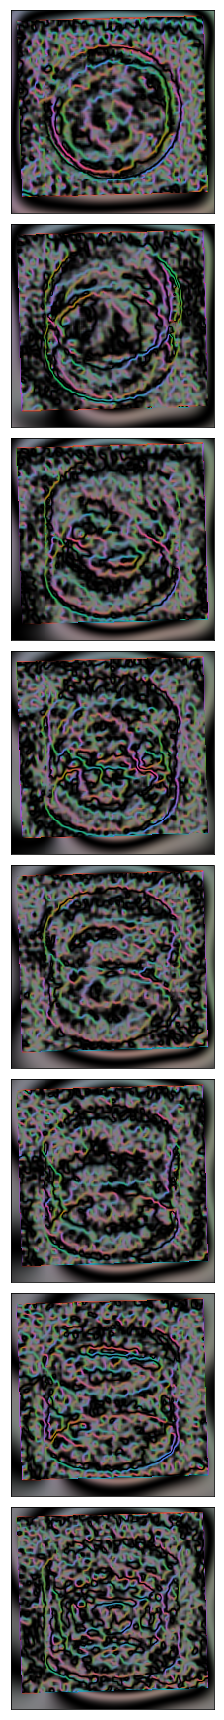

In [ ]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
#sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid']) # where Pyramid situates
print('Python %s on %s' % (sys.version, sys.platform))

import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import pyramid as pr
from scipy.ndimage import rotate, gaussian_filter
pr.plottools.pretty_plots()
import h5py

angles = [0, 28, 44, 50, 54, 58, 61, 65]
fig = plt.figure(figsize=(15,30))
ax = {}
for i, angle in enumerate(angles):
    phasediff_name = './hdf5/pred_loss/phase_{:g}.hdf5'.format(angles[i])
    with h5py.File(phasediff_name, 'r') as hf:
        phase = np.fliplr(rotate(hf['phase'][:], angle=90, reshape=False, order=1))
        mask = np.fliplr(rotate(hf['mask'][:], angle=90, reshape=False, order=0))
        phase = pr.PhaseMap(a=1, phase=phase, mask=mask)
        phase.phase = gaussian_filter(phase.phase, sigma=2) # sigma = 0 when plotting grayscale phase image
    tilt = angle
    ax[i+1] = fig.add_subplot(8, 1, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    # phase.plot_holo(axis=ax[i+1],gain=40,scalebar=False,colorwheel=False,note="{}".format(''))
    phase.plot_phase(axis=ax[i+1],scalebar=False,note="{}".format(''),cbar=False,show_mask=True,cmap='gray',vmax=0.5,vmin=-0.5)
    plt.tight_layout(h_pad=0.4)